# The Milstein Scheme for Stochastic Differential Equations

## Problem

Simulate sample paths of an Itô stochastic differential equation

$$
dX_t = a(X_t, t)\,dt + b(X_t, t)\,dW_t
$$

driven by a Wiener process $W_t$. The Euler-Maruyama scheme (the direct stochastic analogue of
Euler's method) only carries strong order $0.5$: its path-wise error scales like $\sqrt{\Delta t}$,
not $\Delta t$, because it discards a second-order Itô term that isn't negligible at the same order
as the drift/diffusion terms it does keep. The Milstein scheme restores that missing term and
achieves strong order $1.0$.


## Method

**Milstein scheme.** For a fixed time step $\Delta t$ and Wiener increment
$\Delta W_n \sim \mathcal{N}(0, \Delta t)$,

$$
X_{n+1} = X_n + a(X_n, t_n)\,\Delta t + b(X_n, t_n)\,\Delta W_n
        + \tfrac{1}{2}\,b(X_n, t_n)\,b'(X_n, t_n)\,\big[(\Delta W_n)^2 - \Delta t\big]
$$

where $b'$ is the derivative of the diffusion coefficient with respect to $X$. The correction term
comes directly from the Itô-Taylor expansion of $b(X_t)$ along the path; Euler-Maruyama is exactly
this scheme with the correction term dropped.

**Measuring strong convergence order.** Strong order is measured path-wise: for a fixed Brownian
path, refine the time step and track how the numerical solution at time $T$ approaches the true
(or a reference) solution. To keep the comparison meaningful across different $\Delta t$, the *same*
underlying Brownian path is used at every resolution: generate Wiener increments on a very fine grid,
then build each coarser grid's increments by summing consecutive fine increments
(Brownian motion's independent-increments property makes this exact, not an approximation). The
expected absolute error at $T$, averaged over many independent paths, should then scale as
$\Delta t^{p}$ for strong order $p$, visible as a straight line of slope $p$ on a log-log plot.

**Example 1 — Geometric Brownian Motion.** $dX = \mu X\,dt + \sigma X\,dW$ has the closed-form
solution $X_T = X_0\exp\!\big((\mu - \sigma^2/2)T + \sigma W_T\big)$, giving an exact reference to
measure strong error against. Since $b(x) = \sigma x$ and $b'(x) = \sigma$, the Milstein correction
term is $\tfrac{1}{2}\sigma^2 X_n\big[(\Delta W_n)^2 - \Delta t\big]$.

**Example 2 — Cox-Ingersoll-Ross (CIR) process.** $dX = \kappa(\theta - X)\,dt + \sigma\sqrt{X}\,dW$
(the mean-reverting square-root process used for interest rates, and for variance in the Heston
model) has no known closed-form path-wise solution, so its Milstein scheme is instead checked
against a Milstein simulation on a much finer grid. Since $b(x) = \sigma\sqrt{x}$ and
$b'(x) = \sigma/(2\sqrt{x})$, the product $b(x)b'(x) = \sigma^2/2$ is constant, so the correction
term simplifies to $\tfrac{1}{4}\sigma^2\big[(\Delta W_n)^2 - \Delta t\big]$ regardless of $X_n$.
Because $\sqrt{X}$ is undefined for $X<0$ and discretized paths can dip slightly negative even when
the exact process cannot (whenever the Feller condition $2\kappa\theta > \sigma^2$ holds), the scheme
uses **full truncation**: $X_n^+ = \max(X_n, 0)$ wherever $X_n$ appears inside a square root.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "0.85"
plt.rcParams["grid.linestyle"] = "-"


## Example 1: Geometric Brownian Motion — strong convergence order

Euler-Maruyama measured strong order: 0.490 (theory: 0.5)
Milstein measured strong order:       0.994 (theory: 1.0)


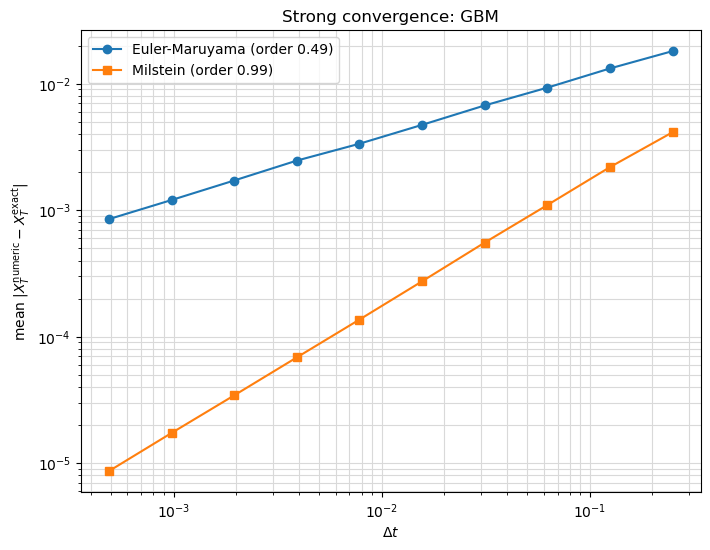

In [2]:
# GBM parameters
mu, sigma, X0, T = 0.08, 0.25, 1.0, 1.0

# Finest grid: all coarser grids' Wiener increments are built by summing these
n_fine_pow = 12
N_fine = 2**n_fine_pow
dt_fine = T / N_fine
n_paths = 2000


def euler_maruyama_gbm(dW, dt):
    X = np.full(dW.shape[0], X0)
    for i in range(dW.shape[1]):
        X = X + mu * X * dt + sigma * X * dW[:, i]
    return X


def milstein_gbm(dW, dt):
    X = np.full(dW.shape[0], X0)
    for i in range(dW.shape[1]):
        dWn = dW[:, i]
        X = X + mu * X * dt + sigma * X * dWn + 0.5 * sigma**2 * X * (dWn**2 - dt)
    return X


dW_fine = rng.normal(0.0, np.sqrt(dt_fine), size=(n_paths, N_fine))
W_T = dW_fine.sum(axis=1)
X_exact = X0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * W_T)

levels = list(range(1, n_fine_pow - 1))
dts, em_errors, milstein_errors = [], [], []
for k in levels:
    M = 2**k
    N_coarse = N_fine // M
    dt = dt_fine * M
    dW_coarse = dW_fine.reshape(n_paths, N_coarse, M).sum(axis=2)

    X_em = euler_maruyama_gbm(dW_coarse, dt)
    X_mil = milstein_gbm(dW_coarse, dt)

    dts.append(dt)
    em_errors.append(np.mean(np.abs(X_em - X_exact)))
    milstein_errors.append(np.mean(np.abs(X_mil - X_exact)))

dts = np.array(dts)
em_errors = np.array(em_errors)
milstein_errors = np.array(milstein_errors)

em_order = np.polyfit(np.log(dts), np.log(em_errors), 1)[0]
milstein_order = np.polyfit(np.log(dts), np.log(milstein_errors), 1)[0]

print(f"Euler-Maruyama measured strong order: {em_order:.3f} (theory: 0.5)")
print(f"Milstein measured strong order:       {milstein_order:.3f} (theory: 1.0)")

plt.figure(figsize=(8, 6))
plt.loglog(dts, em_errors, "o-", label=f"Euler-Maruyama (order {em_order:.2f})")
plt.loglog(dts, milstein_errors, "s-", label=f"Milstein (order {milstein_order:.2f})")
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"mean $|X_T^{\mathrm{numeric}} - X_T^{\mathrm{exact}}|$")
plt.title("Strong convergence: GBM")
plt.legend()
plt.grid(True, which="both")
plt.show()


## Example 2: Cox-Ingersoll-Ross process (full truncation)

Feller condition: 2*kappa*theta = 0.1200 > sigma^2 = 0.0225 -> True


CIR Milstein measured order (vs. fine-grid reference): 1.065
Minimum simulated value across all paths: 0.00539 (should stay non-negative)


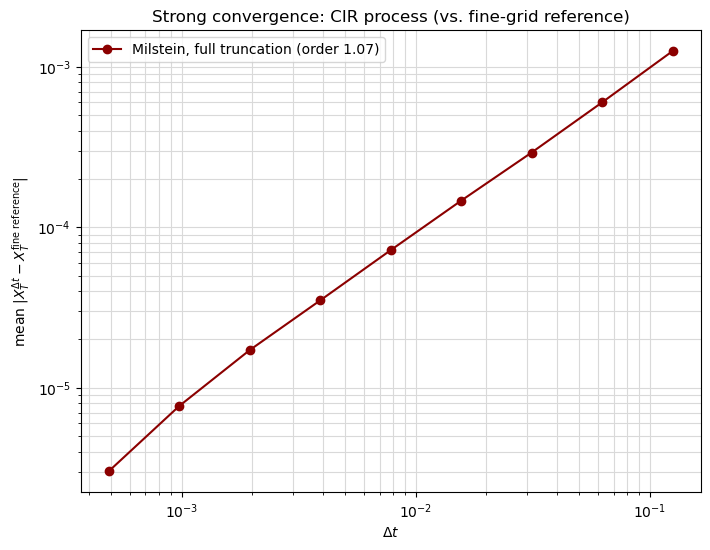

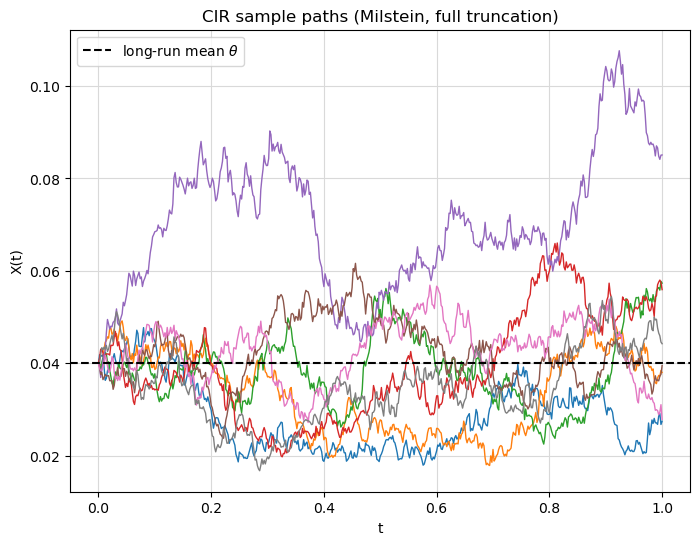

In [3]:
# CIR parameters, chosen to satisfy the Feller condition 2*kappa*theta > sigma^2
kappa, theta, sigma_cir, X0_cir, T_cir = 1.5, 0.04, 0.15, 0.04, 1.0
feller_lhs, feller_rhs = 2 * kappa * theta, sigma_cir**2
print(f"Feller condition: 2*kappa*theta = {feller_lhs:.4f} > sigma^2 = {feller_rhs:.4f} -> "
      f"{feller_lhs > feller_rhs}")


def milstein_cir(dW, dt):
    X = np.full(dW.shape[0], X0_cir)
    for i in range(dW.shape[1]):
        Xp = np.maximum(X, 0.0)
        dWn = dW[:, i]
        X = X + kappa * (theta - Xp) * dt + sigma_cir * np.sqrt(Xp) * dWn + 0.25 * sigma_cir**2 * (dWn**2 - dt)
    return X


n_fine_pow_cir = 12
N_fine_cir = 2**n_fine_pow_cir
dt_fine_cir = T_cir / N_fine_cir
n_paths_cir = 4000

dW_fine_cir = rng.normal(0.0, np.sqrt(dt_fine_cir), size=(n_paths_cir, N_fine_cir))
X_reference = milstein_cir(dW_fine_cir, dt_fine_cir)  # Milstein on the finest grid, used as ground truth

levels_cir = list(range(1, n_fine_pow_cir - 2))
dts_cir, cir_errors = [], []
for k in levels_cir:
    M = 2**k
    N_coarse = N_fine_cir // M
    dt = dt_fine_cir * M
    dW_coarse = dW_fine_cir.reshape(n_paths_cir, N_coarse, M).sum(axis=2)
    X_coarse = milstein_cir(dW_coarse, dt)
    dts_cir.append(dt)
    cir_errors.append(np.mean(np.abs(X_coarse - X_reference)))

dts_cir = np.array(dts_cir)
cir_errors = np.array(cir_errors)
cir_order = np.polyfit(np.log(dts_cir), np.log(cir_errors), 1)[0]
print(f"CIR Milstein measured order (vs. fine-grid reference): {cir_order:.3f}")
print(f"Minimum simulated value across all paths: {X_reference.min():.5f} (should stay non-negative)")

plt.figure(figsize=(8, 6))
plt.loglog(dts_cir, cir_errors, "o-", color="darkred", label=f"Milstein, full truncation (order {cir_order:.2f})")
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"mean $|X_T^{\Delta t} - X_T^{\mathrm{fine\ reference}}|$")
plt.title("Strong convergence: CIR process (vs. fine-grid reference)")
plt.legend()
plt.grid(True, which="both")
plt.show()

# A handful of sample paths, for a qualitative look at the mean-reverting, non-negative behavior
N_plot = 500
dt_plot = T_cir / N_plot
dW_plot = rng.normal(0.0, np.sqrt(dt_plot), size=(8, N_plot))
X_path = np.full(8, X0_cir)
paths = [X_path.copy()]
for i in range(N_plot):
    Xp = np.maximum(X_path, 0.0)
    X_path = X_path + kappa * (theta - Xp) * dt_plot + sigma_cir * np.sqrt(Xp) * dW_plot[:, i] \
        + 0.25 * sigma_cir**2 * (dW_plot[:, i]**2 - dt_plot)
    paths.append(X_path.copy())
paths = np.array(paths)

plt.figure(figsize=(8, 6))
t_grid = np.linspace(0, T_cir, N_plot + 1)
for j in range(8):
    plt.plot(t_grid, paths[:, j], linewidth=1)
plt.axhline(theta, color="black", linestyle="--", label=r"long-run mean $\theta$")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.title("CIR sample paths (Milstein, full truncation)")
plt.legend()
plt.grid(True)
plt.show()
